In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [ ]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [ ]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

In [ ]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

In [ ]:
epochs = 1000
M = 512 
hidden_layers = [256, 256, 256, 256] 

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        u_pred = nn.Dense(1, use_bias=False)(h)
        return u_pred

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [ ]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 2000 
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        sigma_val = jax.nn.softplus(params['params']['raw_sigma'][0])
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e} | Learned Sigma: {sigma_val:.4f}")

In [ ]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()

In [ ]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename="pretrained_helmholtz_mlp.pkl"):
    # Convert JAX DeviceArrays to standard NumPy arrays for safe pickling
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to {filename}")

def load_weights(filename="pretrained_helmholtz_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
    # Convert back to JAX arrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from {filename}")
    return jax_params

# Example Usage:
save_weights(params) 
params = load_weights()

In [ ]:
# EXTRACT FROZEN FRONT-END WEIGHTS
frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = params['params'][dense_name]

# Extract and apply the learned sigma to B_matrix_base
learned_raw_sigma = params['params']['raw_sigma'][0]
learned_sigma = jax.nn.softplus(learned_raw_sigma)
print(f"Applying learned bandwidth (sigma = {learned_sigma:.4f}) to the features...")

# DEFINE FROZEN MODEL (NO FINAL LAYER)
class FrozenFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(1), (1,)) # this is fallback, extracted sigma is applied to B_matrix_base
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = nn.tanh(h)
            
        return h # Outputs shape (256,)

model_frozen = FrozenFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

# BUILD THE PHYSICS & BC MATRICES (SAMPLED)
omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

rng = jax.random.PRNGKey(42)
total_points = x.shape[0]
spatial_batch_size = 2000 # Same batch size used in your training loop

rng, shuffle_key = jax.random.split(rng)
batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)

x_sampled = x[batch_idx]
y_sampled = y[batch_idx]
a_sampled = a_flat[batch_idx]

@jax.jit
def compute_A_pde(x_val, y_val, a_val):
    H = model_frozen.apply(frozen_params, x_val, y_val)
    
    # Isolate the forward pass for derivatives
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    # Second derivatives using purely forward-mode autodiff 
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
    
    Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    return -Laplacian_H - omega_sq * a_val * H

compute_A_pde_vmap = jax.jit(vmap(compute_A_pde))

print(f"Compiling and evaluating PDE matrices for {spatial_batch_size} sampled points...")
chunk_size = 1000
A_pde_chunks = []

for i in range(0, spatial_batch_size, chunk_size):
    x_chunk = x_sampled[i:i + chunk_size]
    y_chunk = y_sampled[i:i + chunk_size]
    a_chunk = a_sampled[i:i + chunk_size]
    
    A_chunk = compute_A_pde_vmap(x_chunk, y_chunk, a_chunk)
    A_pde_chunks.append(A_chunk)

A_pde = jnp.vstack(A_pde_chunks)
b_pde = jnp.zeros((spatial_batch_size, 1))

print("Compiling and evaluating BC matrices...")
A_bc = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x_bc, y_bc)
b_bc = bc_val_array.reshape(-1, 1)

print(f"Finished building matrices! A_pde shape: {A_pde.shape}, A_bc shape: {A_bc.shape}")

# HYPERPARAMETER SWEEP
lambda_bcs = [1e2, 1e3, 1e4, 1e6, 1e8, 1e9, 1e10, 1e11, 1e12]
tik_regs = [1e-3, 1e-4, 1e-5, 1e-6]

best_mse = float('inf')
best_params_combo = {}
best_u_pred = None

I = jnp.eye(A_pde.shape[1]) 

print("\nStarting Sweep:")
print("-" * 80)

all_sweep_preds = {}

for lmbda in lambda_bcs:
    for tik in tik_regs:
        sqrt_lambda = jnp.sqrt(lmbda)
        A = jnp.vstack([A_pde, sqrt_lambda * A_bc])
        B = jnp.vstack([b_pde, sqrt_lambda * b_bc])
        
        # Least Squares Solve
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B)
        
        # Calculate Unscaled PDE Loss (A_pde @ w - b_pde)
        pde_residual = A_pde @ w - b_pde
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        
        # Calculate Unscaled BC Loss (A_bc @ w - b_bc)
        bc_residual = A_bc @ w - b_bc
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Calculate Unscaled Data MSE (Full Grid)
        H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
        u_pred_sweep = H_full @ w
        mse = jnp.mean((u_pred_sweep - u_flat) ** 2)
        
        print(f"Lam: {lmbda:<7.1e} | Tik: {tik:<7.1e} | MSE: {mse:.2e} | PDE: {loss_pde_unscaled:.2e} | BC: {loss_bc_unscaled:.2e}")
        
        all_sweep_preds[(lmbda, tik)] = u_pred_sweep
        
        # Track the best performing combination (still based on MSE)
        if mse < best_mse:
            best_mse = mse
            best_params_combo = {'lambda': lmbda, 'tik_reg': tik, 'w': w}
            best_u_pred = u_pred_sweep

print("-" * 80)
print(f"BEST FOUND: Lambda = {best_params_combo['lambda']}, TikReg = {best_params_combo['tik_reg']}")
print(f"BEST MSE  = {best_mse:.4e}")

In [ ]:
# ==========================================
# E. VISUALIZE BEST SWEEP RESULT
# ==========================================
target_lambda = best_params_combo['lambda']
target_tik = best_params_combo['tik_reg']
target_u_pred = all_sweep_preds[(target_lambda, target_tik)]

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
# u_pred_plot = target_u_pred.reshape(nx, ny).T
u_pred_plot = best_u_pred.reshape(nx,  ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]
 
mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
title_str = f'Direct Solve (λ={target_lambda}, γ={target_tik})'
axes[2].set_title(title_str, fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# DIFFERENTIABLE PSEUDOINVERSE LOOP (WITH PDE AND BC LOSS)
# ==========================================
full_params = load_weights("pretrained_helmholtz_mlp.pkl")

frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = full_params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = full_params['params'][dense_name]

matrix_lmbda = 1e11
sqrt_matrix_lmbda = jnp.sqrt(matrix_lmbda)
loss_pde_weight = 1
loss_bc_weight = 1e4
tik = 1e-4
omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

@jax.jit
def diff_physics_step(current_frozen_params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, x_full, y_full, u_full):
    def compute_all_losses(params):
        def get_H(x_in, y_in):
            return model_frozen.apply(params, x_in, y_in) 
            
        def compute_pde_row(x_val, y_val, a_val):
            H = get_H(x_val, y_val)
            H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
            H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
            Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
            return -Laplacian_H - omega_sq * a_val * H
            
        # Build Matrices
        A_pde_diff = vmap(compute_pde_row)(x_pde, y_pde, a_pde)
        b_pde_diff = jnp.zeros((x_pde.shape[0], 1))
        
        A_bc_diff = vmap(get_H)(x_bc, y_bc)
        b_bc_diff = bc_val_arr.reshape(-1, 1)
        
        A = jnp.vstack([A_pde_diff, sqrt_matrix_lmbda * A_bc_diff])
        B = jnp.vstack([b_pde_diff, sqrt_matrix_lmbda * b_bc_diff])
        
        # RAW MATRIX SOLVE
        I = jnp.eye(A.shape[1])
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w_diff = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
        
        # Unscaled Physics Residuals
        pde_residual = A_pde_diff @ w_diff - b_pde_diff
        bc_residual = A_bc_diff @ w_diff - b_bc_diff
        
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Scaled BC Loss
        loss_pde_scaled = loss_pde_unscaled * loss_pde_weight
        loss_bc_scaled = loss_bc_unscaled * loss_bc_weight
        
        # Calculate True Data MSE
        H_full = vmap(get_H)(x_full, y_full)
        u_pred = H_full @ w_diff
        mse = jnp.mean((u_pred - u_full) ** 2)
        
        # RETURN ALL 4 LOSSES HERE
        return (loss_pde_scaled, loss_bc_scaled, loss_pde_unscaled, loss_bc_unscaled), mse

    loss_tuple, vjp_fn, mse = jax.vjp(compute_all_losses, current_frozen_params, has_aux=True)
    l_pde_scaled, l_bc_scaled, l_pde_unscaled, l_bc_unscaled = loss_tuple
    
    # Pull gradients (Note the 4-item tuples to match the 4 returned losses)
    total_grads = vjp_fn((1.0, 1.0, 0.0, 0.0))[0]
    pde_grads = vjp_fn((1.0, 0.0, 0.0, 0.0))[0]
    bc_grads = vjp_fn((0.0, 1.0, 0.0, 0.0))[0]
    
    total_loss = l_pde_scaled + l_bc_scaled
    
    return total_loss, l_pde_unscaled, l_pde_scaled, l_bc_unscaled, l_bc_scaled, mse, total_grads, pde_grads, bc_grads

# Meta-Training Loop Setup
meta_optimizer = optax.adamw(learning_rate=1e-4) 
meta_opt_state = meta_optimizer.init(frozen_params)

N_pde_test = 2000
rng = jax.random.PRNGKey(99)
epochs = 500 

print("Starting Pretrained Physics-Only Loop (Tracking Data MSE)...")
for epoch in range(epochs):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, x.shape[0], shape=(N_pde_test,), replace=False)
    
    x_pde_test = x[batch_idx]
    y_pde_test = y[batch_idx]
    a_pde_test = a_flat[batch_idx]

    # Unpack all variables correctly
    total_loss, l_pde_unscaled, l_pde_scaled, l_bc_unscaled, l_bc_scaled, mse, total_grads, pde_grads, bc_grads = diff_physics_step(
        frozen_params, x_pde_test, y_pde_test, a_pde_test, x_bc, y_bc, bc_val_array, x, y, u_flat
    )

    total_grad_mag = optax.global_norm(total_grads)
    pde_grad_mag = optax.global_norm(pde_grads)
    bc_grad_mag = optax.global_norm(bc_grads)
    
    updates, meta_opt_state = meta_optimizer.update(total_grads, meta_opt_state, params=frozen_params)
    frozen_params = optax.apply_updates(frozen_params, updates)
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:<3} | Data MSE: {mse:.4e} | Total Loss (scaled): {total_loss:.4e}")
        print(f"            ├─ PDE Loss   => Unscaled: {l_pde_unscaled:.4e} | Scaled: {l_pde_scaled:.4e}")
        print(f"            ├─ BC Loss    => Unscaled: {l_bc_unscaled:.4e} | Scaled: {l_bc_scaled:.4e}")
        print(f"            └─ Grad Norms => Total: {total_grad_mag:.4e} | PDE: {pde_grad_mag:.4e} | BC: {bc_grad_mag:.4e}")

In [ ]:
w_learned = params['params']['Dense_4']['kernel']

print(f"Original Adam Weights Shape: {w_learned.shape}")

H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)

# u_pred_manual = (H_full @ w_learned) + b_learned
u_pred_manual = (H_full @ w_learned)

mse_manual = jnp.mean((u_pred_manual - u_flat) ** 2)
print(f"Manual Multiplication MSE (Adam's Weights): {mse_manual:.4e}")
print(f"Best Pseudoinverse MSE (from Sweep):      {best_mse:.4e}")

# ==========================================
# VISUALIZE THE WEIGHTS (Adam vs. Pseudoinverse)
# ==========================================
w_pseudo = best_params_combo['w']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(w_learned, label='Adam Learned Weights', alpha=0.8, linewidth=2)
axes[0].plot(w_pseudo, label='Pseudoinverse Weights', alpha=0.8, linewidth=2, linestyle='dashed')
axes[0].set_title("Weight Comparison: Adam vs. Pseudoinverse", fontsize='large')
axes[0].set_xlabel("Feature Index (0 to 255)")
axes[0].set_ylabel("Weight Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(w_learned, w_pseudo, alpha=0.6, color='purple')
# Add a y=x reference line
min_val = min(jnp.min(w_learned), jnp.min(w_pseudo))
max_val = max(jnp.max(w_learned), jnp.max(w_pseudo))
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Match (y=x)')
axes[1].set_title("Weight Correlation", fontsize='large')
axes[1].set_xlabel("Adam Weights")
axes[1].set_ylabel("Pseudoinverse Weights")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
@jax.jit
def debug_pde_magnitudes(x_val, y_val, a_val):
    # Isolate the forward pass
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    H = get_H(x_val, y_val)
    
    # Calculate second derivatives
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
    Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    
    # Calculate the omega term
    reaction_term = omega_sq * a_val * H
    
    # Return the absolute mean of both terms for this specific coordinate
    return jnp.mean(jnp.abs(Laplacian_H)), jnp.mean(jnp.abs(reaction_term))

debug_vmap = jax.jit(vmap(debug_pde_magnitudes))

# Run the test on a chunk of your spatial points
lap_mags, react_mags = debug_vmap(x_sampled[:5000], y_sampled[:5000], a_sampled[:5000])

print(f"Average Magnitude of Laplacian (Network Derivatives): {jnp.mean(lap_mags):.2f}")
print(f"Average Magnitude of Reaction Term (Omega^2 * a * H): {jnp.mean(react_mags):.2f}")

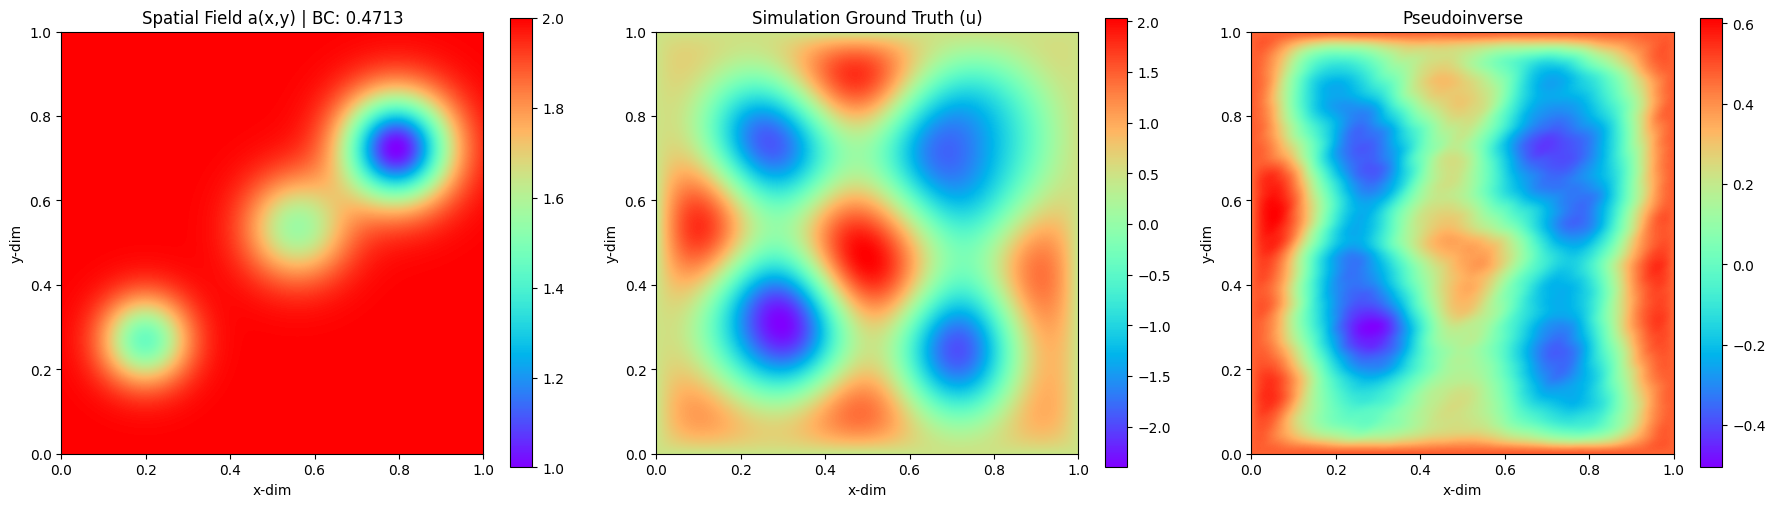

In [20]:
def get_final_w(current_params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr):
    def get_H(x_in, y_in):
        return model_frozen.apply(current_params, x_in, y_in) 
        
    def compute_pde_row(x_val, y_val, a_val):
        H = get_H(x_val, y_val)
        H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
        H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
        Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
        return -Laplacian_H - omega_sq * a_val * H
        
    A_pde_final = vmap(compute_pde_row)(x_pde, y_pde, a_pde)
    b_pde_final = jnp.zeros((x_pde.shape[0], 1))
    
    A_bc_final = vmap(get_H)(x_bc, y_bc)
    b_bc_final = bc_val_arr.reshape(-1, 1)
    
    A = jnp.vstack([A_pde_final, sqrt_matrix_lmbda * A_bc_final])
    B = jnp.vstack([b_pde_final, sqrt_matrix_lmbda * b_bc_final])
    
    I = jnp.eye(A.shape[1])
    A_T_A = A.T @ A
    A_T_B = A.T @ B
    w_scaled = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
    
    return w_scaled

# Pass the updated 'frozen_params' to calculate the final optimal w
final_w = get_final_w(frozen_params, x_pde_test, y_pde_test, a_pde_test, x_bc, y_bc, bc_val_array)

# Pass the updated 'frozen_params' to extract the full grid features
H_full_grid = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
u_pred_full = H_full_grid @ final_w

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pseudoinverse', fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [ ]:
# import h5py
# import numpy as np
# import matplotlib.pyplot as plt
# import jax.scipy.signal
# from jax import numpy as jnp
# from pathlib import Path

# # ==========================================
# # 1. SETUP & DATA LOADING
# # ==========================================
# DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
# FILE_PATH = DATA_DIR / "Helmholtz.h5"

# sample_idx = 11
# sample_key = f"Sample_{sample_idx}"

# print(f"Extracting raw data for {sample_key}...")
# with h5py.File(FILE_PATH, 'r') as f:
#     a_grid = jnp.array(f[sample_key]['a'][:])
#     u_grid = jnp.array(f[sample_key]['u'][:])

# # ==========================================
# # 2. DISCRETE PHYSICS PARAMETERS
# # ==========================================
# # The spatial step size
# h = 1.0 / 128.0

# # The TRUE dataset constant we discovered
# omega_sq = 2*((5.0 * jnp.pi / 2.0) ** 2)

# # The standard 5-point discrete Laplacian stencil
# laplacian_kernel = jnp.array([
#     [0.0,  1.0, 0.0],
#     [1.0, -4.0, 1.0],
#     [0.0,  1.0, 0.0]
# ]) / (h ** 2)

# # ==========================================
# # 3. CALCULATE THE PDE RESIDUAL
# # ==========================================
# # Apply the convolution to find the discrete Laplacian
# # mode='valid' strips the 1-pixel outer border to prevent edge-wrapping artifacts
# laplacian_u = jax.scipy.signal.convolve2d(u_grid, laplacian_kernel, mode='valid')

# # Slice the 'a' and 'u' grids to match the 126x126 'valid' interior
# a_valid = a_grid[1:-1, 1:-1]
# u_valid = u_grid[1:-1, 1:-1]

# # The Helmholtz Residual: -Laplacian(u) - omega^2 * a * u = 0
# reaction_term = omega_sq * a_valid * u_valid
# pde_residual = -laplacian_u - reaction_term

# # ==========================================
# # 4. METRICS & VALIDATION
# # ==========================================
# # Calculate how close the residual is to absolute zero
# mae = jnp.mean(jnp.abs(pde_residual))
# mse = jnp.mean(pde_residual ** 2)
# max_error = jnp.max(jnp.abs(pde_residual))

# print("-" * 50)
# print(f"RAW SIMULATION PDE RESIDUAL METRICS")
# print(f"Using omega_sq = {omega_sq:.4f}")
# print("-" * 50)
# print(f"Mean Absolute Error (MAE): {mae:.4e}")
# print(f"Mean Squared Error (MSE):  {mse:.4e}")
# print(f"Maximum Point Error:       {max_error:.4e}")
# print("-" * 50)

# # ==========================================
# # 5. VISUALIZATION
# # ==========================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# ext = [0, 1, 0, 1]

# # Plot Spatial Field
# mesh1 = axes[0].imshow(a_grid.T, origin='lower', cmap='rainbow', extent=ext)
# fig.colorbar(mesh1, ax=axes[0])
# axes[0].set_title('Spatial Field a(x,y)')

# # Plot Ground Truth u
# mesh2 = axes[1].imshow(u_grid.T, origin='lower', cmap='rainbow', extent=ext)
# fig.colorbar(mesh2, ax=axes[1])
# axes[1].set_title('Simulation Ground Truth (u)')

# # Plot the PDE Residual
# # Using a diverging colormap (seismic) centered at 0 to easily spot positive/negative errors
# vmax = float(jnp.max(jnp.abs(pde_residual)))
# mesh3 = axes[2].imshow(pde_residual.T, origin='lower', cmap='seismic', extent=ext, vmin=-vmax, vmax=vmax)
# fig.colorbar(mesh3, ax=axes[2])
# axes[2].set_title('Raw Data PDE Residual (Error)')

# plt.tight_layout()
# plt.show()

In [ ]:
# import h5py
# import numpy as np
# import jax.scipy.signal
# from jax import numpy as jnp
# from tqdm.auto import tqdm

# # 1. Physics constants from the paper
# omega_sq_paper = (5.0 * jnp.pi / 2.0) ** 2  # ~61.685
# h = 1.0 / 128.0

# # Standard 5-point discrete Laplacian stencil
# laplacian_kernel = jnp.array([
#     [0.0,  1.0, 0.0],
#     [1.0, -4.0, 1.0],
#     [0.0,  1.0, 0.0]
# ]) / (h ** 2)

# # 2. Open the file and prepare to track results
# all_sample_constants = []

# print("Running discrete physics audit across all dataset samples...")
# with h5py.File(FILE_PATH, 'r') as f:
#     # Get all sample keys (Sample_0, Sample_1, etc.)
#     sample_keys = list(f.keys())
    
#     # Run through every sample with a progress bar
#     for key in tqdm(sample_keys, desc="Auditing Samples"):
#         a_grid = jnp.array(f[key]['a'][:])
#         u_grid = jnp.array(f[key]['u'][:])
        
#         # Compute the discrete Laplacian of the raw ground-truth grid
#         # mode='valid' cuts out the outer boundary layer to avoid boundary edge noise
#         laplacian_u_raw = jax.scipy.signal.convolve2d(
#             u_grid, laplacian_kernel, mode='valid'
#         )
        
#         # Align u and a to match the inner 126x126 valid region
#         a_valid = a_grid[1:-1, 1:-1]
#         u_valid = u_grid[1:-1, 1:-1]
        
#         # Calculate: omega^2 = -Laplacian(u) / (a * u)
#         # Avoid division by zero where the wave passes through zero crossings
#         mask = jnp.abs(u_valid) > 0.1
        
#         implied_constants = jnp.where(mask, -laplacian_u_raw / (a_valid * u_valid), jnp.nan)
        
#         # Take the median of this sample to robustly ignore any localized pixel spikes
#         sample_median = jnp.nanmedian(implied_constants)
        
#         # Append if it's a valid numerical result
#         if not jnp.isnan(sample_median):
#             all_sample_constants.append(float(sample_median))

# # 3. Compute final metrics across the entire dataset
# all_sample_constants = np.array(all_sample_constants)
# dataset_mean_constant = np.mean(all_sample_constants)
# dataset_median_constant = np.median(all_sample_constants)

# print("\n" + "="*50)
# print("             DATASET PHYSICS VERIFICATION")
# print("="*50)
# print(f"Paper's Stated omega_sq:         {omega_sq_paper:.4f}")
# print(f"Dataset Expected (2x Stated):    {2 * omega_sq_paper:.4f}")
# print("-"*50)
# print(f"Actual Dataset Mean omega_sq:    {dataset_mean_constant:.4f}")
# print(f"Actual Dataset Median omega_sq:  {dataset_median_constant:.4f}")
# print(f"Empirical Scale Factor:          {dataset_median_constant / omega_sq_paper:.4f}x")
# print("="*50)

In [ ]:
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import jax.scipy.signal
from jax import numpy as jnp
from pathlib import Path

# ==========================================
# 1. SETUP
# ==========================================
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"
sample_idx = 0  # Try a few different samples (0, 11, 42)
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_grid = jnp.array(f[sample_key]['a'][:])
    u_grid = jnp.array(f[sample_key]['u'][:])

h = 1.0 / 128.0
laplacian_kernel = jnp.array([[0.0, 1.0, 0.0],
                              [1.0, -4.0, 1.0],
                              [0.0, 1.0, 0.0]]) / (h ** 2)

# ==========================================
# 2. CALCULATE LOCAL PHYSICS
# ==========================================
laplacian_u_raw = jax.scipy.signal.convolve2d(u_grid, laplacian_kernel, mode='valid')
a_valid = a_grid[1:-1, 1:-1]
u_valid = u_grid[1:-1, 1:-1]

# C = -Laplacian(u) / (a * u)
implied_c_grid = -laplacian_u_raw / (a_valid * u_valid)

# Mask out areas where the wave is crossing zero to avoid divide-by-zero artifacts
# We only care about the physics at the peaks and troughs of the wave
mask = jnp.abs(u_valid) > 0.05
clean_c_grid = jnp.where(mask, implied_c_grid, jnp.nan)

median_c = float(jnp.nanmedian(clean_c_grid))

# ==========================================
# 3. VISUALIZE THE SMOKING GUN
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(a_grid.T, origin='lower', cmap='rainbow')
axes[0].set_title('Spatial Medium (a)')

axes[1].imshow(u_grid.T, origin='lower', cmap='seismic')
axes[1].set_title('Wave Output (u)')

# We use SymLogNorm to handle extreme outliers without washing out the color
im3 = axes[2].imshow(clean_c_grid.T, origin='lower', cmap='RdBu_r', 
                     norm=SymLogNorm(linthresh=50, vmin=median_c - 200, vmax=median_c + 200))
axes[2].set_title(f'Implied Physics Constant C (Median: {median_c:.2f})')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()